
| <h1> **Hands-on Activity 10.1** </h1> | <h1> **WData Analysis using Python** </h1> |
|--- | --- |
Name: | Rubang, Jethro Aaron S.<br>
Course and Section: |  CPE 311-CPE22S3<br>
Instructor: | Eng. Neal Barton James Matira
Date Performed: | April 7, 2026
Date Submitted: | April 7, 2026


<hr>


In [22]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('world_health_data.csv')

In [23]:
# 2. TRANSFORM: Clean and Filter for ASEAN
asean_countries = [
    'Brunei Darussalam', 'Cambodia', 'Indonesia', 'Lao PDR',
    'Malaysia', 'Myanmar', 'Philippines', 'Singapore',
    'Thailand', 'Viet Nam'
]
df_asean = df_raw[df_raw['country'].isin(asean_countries)].copy()

In [24]:
# TRANSFORM: Handle Missing Values
df_asean = df_asean.sort_values(['country', 'year'])

In [25]:
# Use Forward Fill (ffill) and Backward Fill (bfill) to fill gaps in reporting
df_asean = df_asean.groupby('country', group_keys=False).apply(lambda x: x.ffill().bfill())

C:\Users\jethr\AppData\Local\Temp\ipykernel_12300\2571335273.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_asean = df_asean.groupby('country', group_keys=False).apply(lambda x: x.ffill().bfill())


In [26]:
# TRANSFORM: Feature Engineering (Creating the "Status" column for the Gap Analysis)
rich_nations = ['Singapore', 'Brunei Darussalam', 'Malaysia', 'Thailand']
df_asean['Income_Status'] = df_asean['country'].apply(
    lambda x: 'High/Upper-Mid Income' if x in rich_nations else 'Developing/Lower-Mid Income'
)

In [27]:
# LOAD: Save the cleaned dataset for your submission
df_asean.to_csv('asean_health_cleaned.csv', index=False)

### Descriptive Anlysis

Visual 1 saved: 'visual_1_descriptive_gap.png'


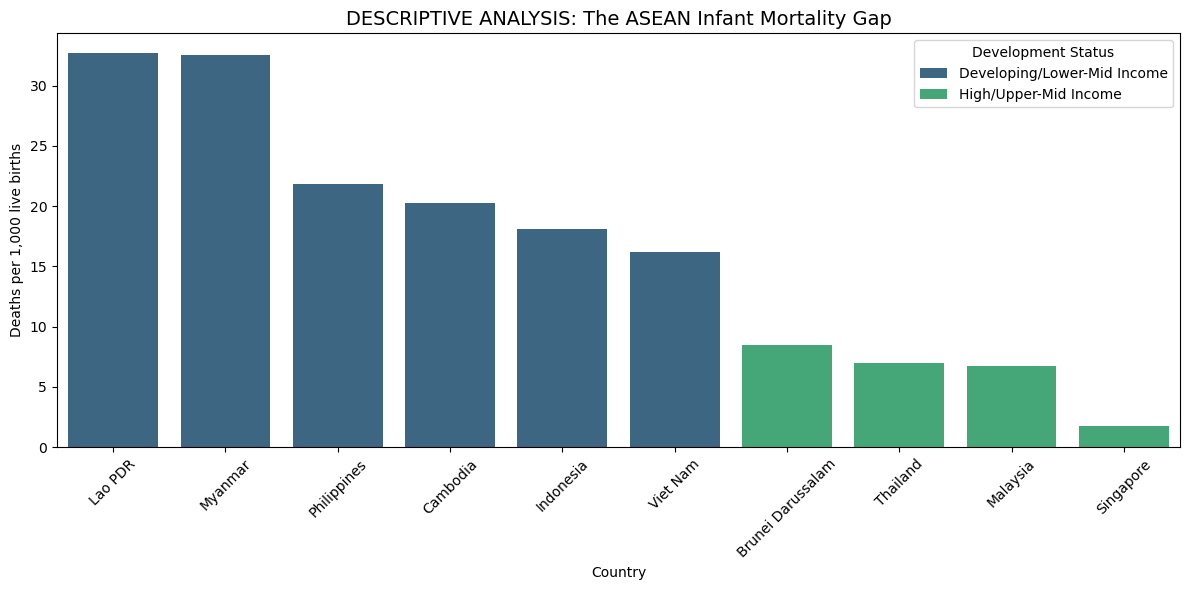

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# We take the latest available data to show the current "Gap"
latest_df = df_asean.sort_values('year').groupby('country').tail(1)

plt.figure(figsize=(12, 6))
sns.barplot(data=latest_df.sort_values('infant_mortality', ascending=False), 
            x='country', y='infant_mortality', hue='Income_Status', palette='viridis')

plt.title('DESCRIPTIVE ANALYSIS: The ASEAN Infant Mortality Gap', fontsize=14)
plt.ylabel('Deaths per 1,000 live births')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.legend(title='Development Status')
plt.tight_layout()
plt.savefig('visual_1_descriptive_gap.png')
print("Visual 1 saved: 'visual_1_descriptive_gap.png'")

1. Descriptive Analysis: The Survival Gap

The first chart compares the most recent information on infant mortality among ASEAN countries. But what stands out here is the "Health Gap." Although we all belong to the same region, it does not mean that there is equality in results.

The countries that are categorized as high/upper-mid income (Singapore and Malaysia) have extremely low columns, implying few infant deaths. But those that are classified as Developing have extremely high bars. It is clear from the disparity between Singapore's infant mortality rate (1.8) and that of Lao PDR (32.7). It can be concluded that the survival opportunity depends on the economic status of the country.

### Correlation Analysis

Visual 2 saved: 'visual_2_correlation_cause_effect.png'



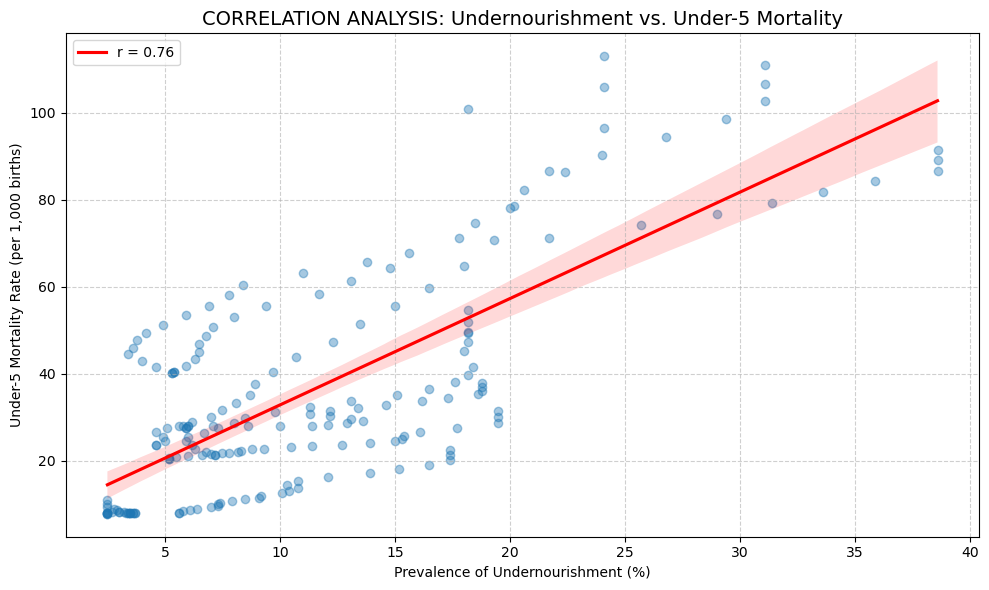

In [29]:
corr_subset = df_asean.dropna(subset=['prev_undernourishment', 'under_5_mortality'])

r_value = corr_subset['prev_undernourishment'].corr(corr_subset['under_5_mortality'])

plt.figure(figsize=(10, 6))
sns.regplot(data=corr_subset, x='prev_undernourishment', y='under_5_mortality', 
            scatter_kws={'alpha':0.4}, line_kws={'color':'red', 'label': f'r = {r_value:.2f}'})

plt.title('CORRELATION ANALYSIS: Undernourishment vs. Under-5 Mortality', fontsize=14)
plt.xlabel('Prevalence of Undernourishment (%)')
plt.ylabel('Under-5 Mortality Rate (per 1,000 births)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('visual_2_correlation_cause_effect.png')
print("Visual 2 saved: 'visual_2_correlation_cause_effect.png'\n")

2. Correlation Analysis: Effect of Nutrition

In the second phase of my research, I attempted to determine the cause of such high mortality rates. I performed a correlation between Undernourishment and Under-5 Mortality.

The outcome provided me with an r-value of 0.76, which is considered a strong positive correlation in statistical analysis. This implies that as the hunger level rises, the under-five mortality rate increases proportionally. The increasing trend is shown in the form of a red regression line in the graph below, and it demonstrates that achieving SDG goal three requires solving the problem of SDG two first.

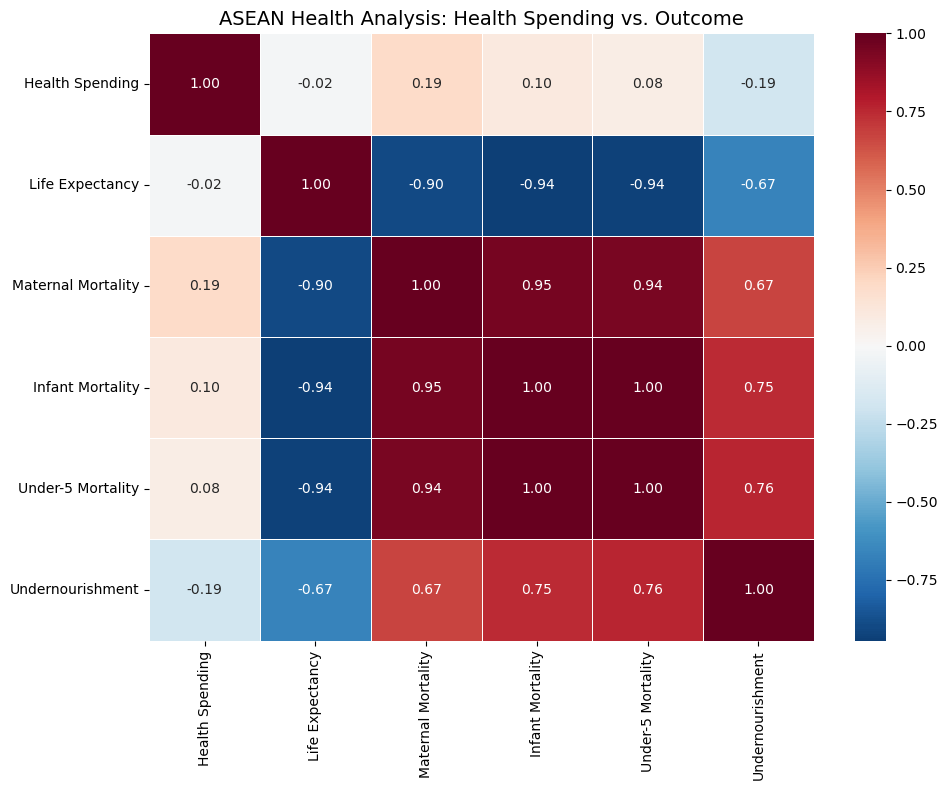

In [31]:

cols_of_interest = {
    'health_exp': 'Health Spending',
    'life_expect': 'Life Expectancy',
    'maternal_mortality': 'Maternal Mortality',
    'infant_mortality': 'Infant Mortality',
    'under_5_mortality': 'Under-5 Mortality',
    'prev_undernourishment': 'Undernourishment'
}
df_corr = df_asean[list(cols_of_interest.keys())].rename(columns=cols_of_interest)

# 4. Create the Heatmap
plt.figure(figsize=(10, 8))
# 'annot=True' puts the actual r-values in the boxes
# 'cmap=RdBu_r' makes Blue=Positive and Red=Negative correlation
correlation_matrix = df_corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title('ASEAN Health Analysis: Health Spending vs. Outcome', fontsize=14)
plt.tight_layout()
plt.savefig('asean_health_heatmap.png')
plt.show()

3. The Heatmap: An Overview of Health 

Last but not least, I created a Correlation Heatmap to find out how these different variables correlate with each other. This is the key piece of the puzzle that gives us an overview of the "Full Ecosystem".

Spending vs. Effectiveness: Interestingly enough, the amount spent on health care does not necessarily mean that it correlates with all other indicators. It means that not only do we need money, but we need efficient use of them.

Life Expectancy: We can easily spot a bunch of red cells (negative correlations) between mortality and life expectancy. Naturally, if we reduce infant and maternal mortality rates in the country, its overall life expectancy will increase dramatically.

The Bottom Line: Thus, the heatmap proved our point regarding the strong connection between Maternal, Infant, and Under-5 mortality.

## Conclusion

To sum it up, it is clear from my analysis that the health issue in ASEAN can be explained from two perspectives. First, there is an income gap, which leads to a health gap. Second, it is evident from the results that malnutrition causes mortality. Therefore, I recommend that the governments of ASEAN countries invest their scarce resources in nutrition programs.